Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from lightgbm import LGBMRegressor


Load and inspect the dataset

In [2]:
# Load dataset
df = pd.read_csv("boralesgamuwa_weather_2025_01_01_to_2025_12_31_15min_interpolated_power_added_final_set.csv")

# Convert timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Sort by time (VERY IMPORTANT)
df = df.sort_values("timestamp").reset_index(drop=True)

df.head()


,timestamp,temperature_C,humidity_percent,cloud_cover_percent,solar_irradiance_Wm2,wind_speed_ms,solar_normalize
0,2025-01-01 00:00:00,24.2,92.0,100.0,0.0,8.100,0.0
1,2025-01-01 00:15:00,24.1,92.5,100.0,0.0,8.275,0.0
2,2025-01-01 00:30:00,24.0,93.0,100.0,0.0,8.450,0.0
3,2025-01-01 00:45:00,23.9,93.5,100.0,0.0,8.625,0.0
4,2025-01-01 01:00:00,23.8,94.0,100.0,0.0,8.800,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   timestamp             35040 non-null  datetime64[ns]
 1   temperature_C         35040 non-null  float64       
 2   humidity_percent      35040 non-null  float64       
 3   cloud_cover_percent   35040 non-null  float64       
 4   solar_irradiance_Wm2  35040 non-null  float64       
 5   wind_speed_ms         35040 non-null  float64       
 6   solar_normalize       34956 non-null  float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 1.9 MB


Clean the dataset

In [4]:

# 2) Interpolate missing values (linear for time series)
df = df.interpolate(method="linear")

# 4) Check dataset info again
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   timestamp             35040 non-null  datetime64[ns]
 1   temperature_C         35040 non-null  float64       
 2   humidity_percent      35040 non-null  float64       
 3   cloud_cover_percent   35040 non-null  float64       
 4   solar_irradiance_Wm2  35040 non-null  float64       
 5   wind_speed_ms         35040 non-null  float64       
 6   solar_normalize       35040 non-null  float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 1.9 MB
None


In [5]:

df.head()

,timestamp,temperature_C,humidity_percent,cloud_cover_percent,solar_irradiance_Wm2,wind_speed_ms,solar_normalize
0,2025-01-01 00:00:00,24.2,92.0,100.0,0.0,8.100,0.0
1,2025-01-01 00:15:00,24.1,92.5,100.0,0.0,8.275,0.0
2,2025-01-01 00:30:00,24.0,93.0,100.0,0.0,8.450,0.0
3,2025-01-01 00:45:00,23.9,93.5,100.0,0.0,8.625,0.0
4,2025-01-01 01:00:00,23.8,94.0,100.0,0.0,8.800,0.0


In [6]:
df.tail()

,timestamp,temperature_C,humidity_percent,cloud_cover_percent,solar_irradiance_Wm2,wind_speed_ms,solar_normalize
35035,2025-12-31 22:45:00,24.15,94.0,100.0,0.0,6.2,0.0
35036,2025-12-31 23:00:00,24.30,94.0,100.0,0.0,6.0,0.0
35037,2025-12-31 23:15:00,24.45,94.0,100.0,0.0,5.8,0.0
35038,2025-12-31 23:30:00,24.60,94.0,100.0,0.0,5.6,0.0
35039,2025-12-31 23:45:00,24.75,94.0,100.0,0.0,5.4,0.0


Exploratory Data Analysis (EDA)

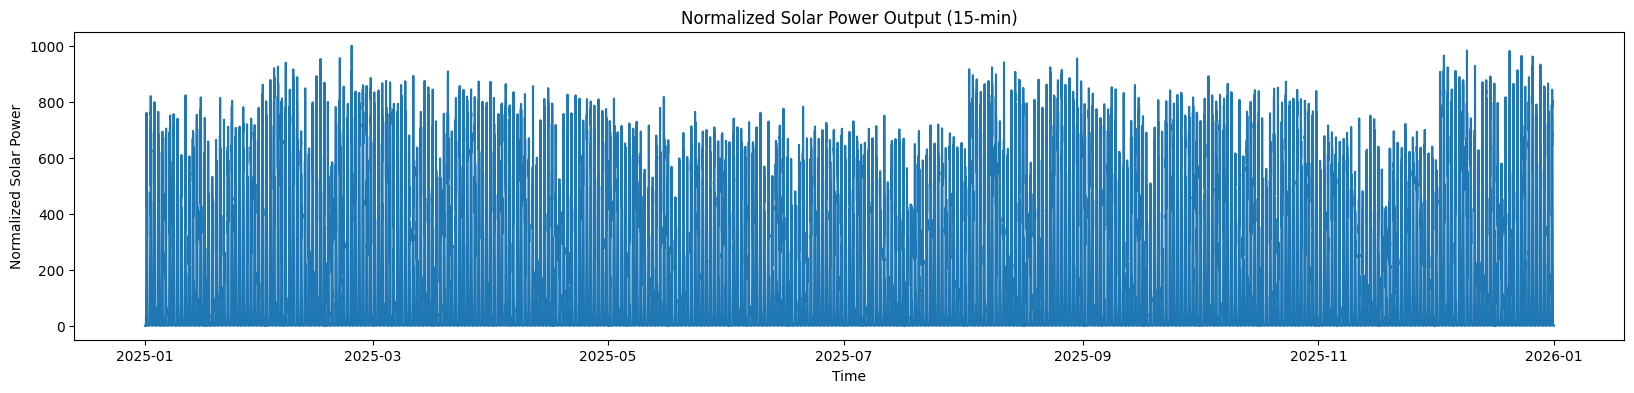

In [7]:
plt.figure(figsize=(20,4))
plt.plot(df["timestamp"], df["solar_normalize"])
plt.title("Normalized Solar Power Output (15-min)")
plt.xlabel("Time")
plt.ylabel("Normalized Solar Power")
plt.show()


Correlation with weather variables

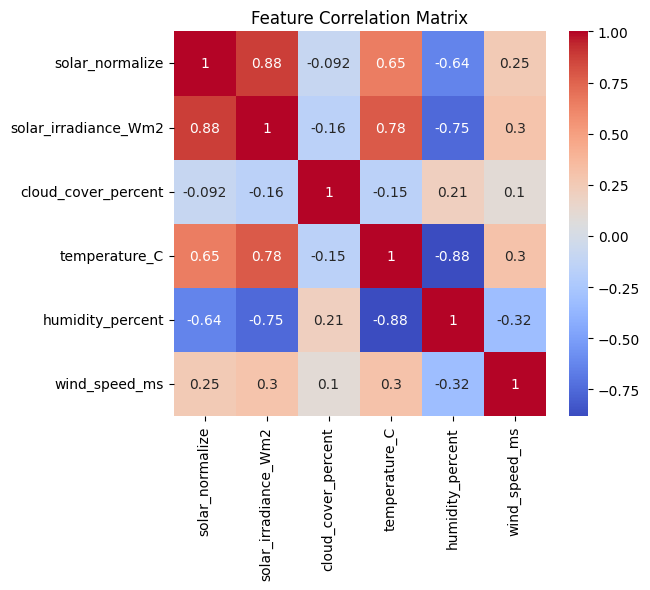

In [8]:
plt.figure(figsize=(6,5))
sns.heatmap(
    df[[
        "solar_normalize",
        "solar_irradiance_Wm2",
        "cloud_cover_percent",
        "temperature_C",
        "humidity_percent",
        "wind_speed_ms"
    ]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Feature Correlation Matrix")
plt.show()


Time-based features

In [9]:
df["hour"] = df["timestamp"].dt.hour
df["minute"] = df["timestamp"].dt.minute
df["dayofyear"] = df["timestamp"].dt.dayofyear

Define inputs and target

In [10]:
y = df["solar_normalize"]

In [11]:
X = df[
    [
        "solar_irradiance_Wm2",
        "temperature_C",
        "wind_speed_ms",
        "hour",
        "minute",
        "dayofyear"
    ]
]


In [12]:
y.head()

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: solar_normalize, dtype: float64

In [13]:
X.head()    

,solar_irradiance_Wm2,temperature_C,wind_speed_ms,hour,minute,dayofyear
0,0.0,24.2,8.100,0,0,1
1,0.0,24.1,8.275,0,15,1
2,0.0,24.0,8.450,0,30,1
3,0.0,23.9,8.625,0,45,1
4,0.0,23.8,8.800,1,0,1


In [14]:
len(X)

35040

Train–test split (TIME-AWARE)

In [15]:
train_size = int(0.8 * len(df))

X_train = X.iloc[:train_size]
X_test  = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]

In [37]:
len(X_train), len(X_test), len(y_train), len(y_test)

(28032, 7008, 28032, 7008)

Feature scaling (important for later LSTM)

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Train baseline LightGBM model

In [17]:
lgb_model = LGBMRegressor(
    subsample=0.8, num_leaves=20, n_estimators=300, max_depth=6, learning_rate=0.1, colsample_bytree=0.7
)

lgb_model.fit(X_train_scaled, y_train)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001264 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1050
[LightGBM] [Info] Number of data points in the train set: 28032, number of used features: 6
[LightGBM] [Info] Start training from score 170.913669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMRegressor(colsample_bytree=0.7, max_depth=6, n_estimators=300,
              num_leaves=20, subsample=0.8)

Model evaluation

In [18]:
y_pred = lgb_model.predict(X_test_scaled)

c:\Users\HP\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Error metrics

In [19]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 68.8219
RMSE : 125.6784
R²   : 0.7436


Actual vs Predicted plot

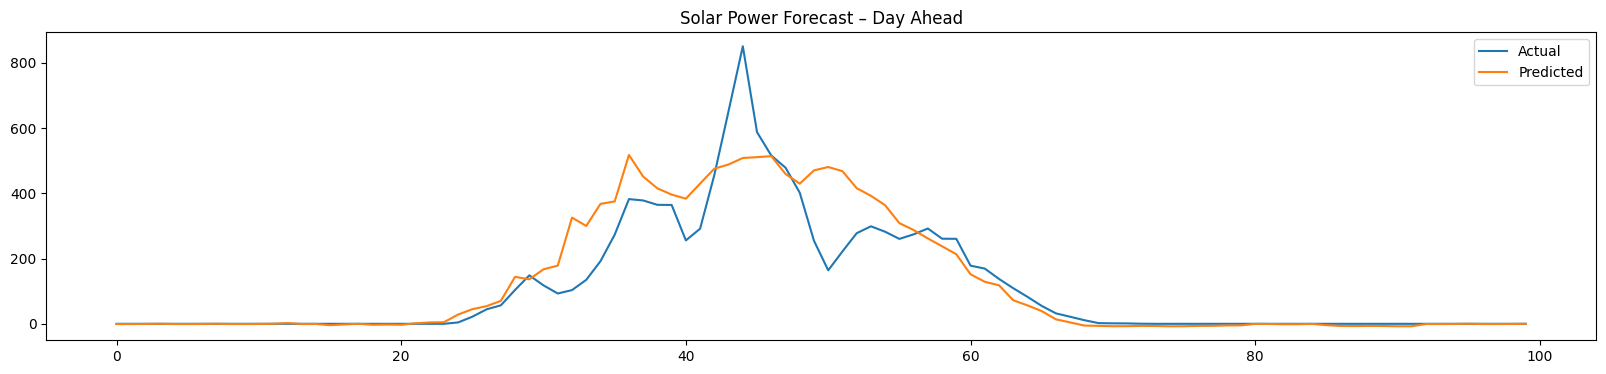

In [20]:
plt.figure(figsize=(20,4))
plt.plot(y_test.values[100:200], label="Actual")
plt.plot(y_pred[100:200], label="Predicted")
plt.legend()
plt.title("Solar Power Forecast – Day Ahead")
plt.show()


Residual analysis (VERY IMPORTANT for next stage)

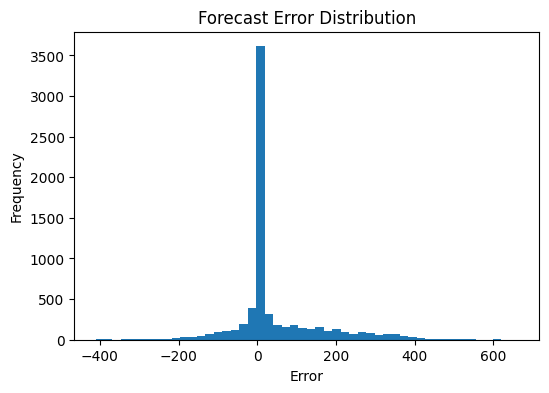

In [21]:
residuals = y_test.values - y_pred

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=50)
plt.title("Forecast Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()


Prepare LSTM inputs

In [22]:
#to increase the dataset size
y_pred2 = lgb_model.predict(X_train_scaled)
df_lstm = df.iloc[:train_size].copy()

# df_lstm["lgb_pred"] = y_pred
df_lstm["lgb_pred"] = y_pred2
df_lstm["residual"] = df_lstm["solar_normalize"] - df_lstm["lgb_pred"]

df_lstm.head()

c:\Users\HP\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,timestamp,temperature_C,humidity_percent,cloud_cover_percent,solar_irradiance_Wm2,wind_speed_ms,solar_normalize,hour,minute,dayofyear,lgb_pred,residual
0,2025-01-01 00:00:00,24.2,92.0,100.0,0.0,8.100,0.0,0,0,1,-3.652330,3.652330
1,2025-01-01 00:15:00,24.1,92.5,100.0,0.0,8.275,0.0,0,15,1,-3.669722,3.669722
2,2025-01-01 00:30:00,24.0,93.0,100.0,0.0,8.450,0.0,0,30,1,-4.053092,4.053092
3,2025-01-01 00:45:00,23.9,93.5,100.0,0.0,8.625,0.0,0,45,1,-3.952419,3.952419
4,2025-01-01 01:00:00,23.8,94.0,100.0,0.0,8.800,0.0,1,0,1,-4.728404,4.728404


Select features for LSTM

In [23]:
lstm_features = [
    "solar_normalize",
    "lgb_pred",
    "residual",
]

Create LSTM sequences

In [24]:
LOOKBACK = 96   # 8 × 15 min = 2 hours

Function to create sequences

In [25]:
def create_sequences(data, features, target, lookback):
    X, y = [], []
    
    for i in range(lookback, len(data)):
        X.append(data[features].iloc[i-lookback:i].values)
        y.append(data[target].iloc[i])
        
    return np.array(X), np.array(y)


Create LSTM dataset

In [26]:
X_lstm, y_lstm = create_sequences(
    df_lstm,
    lstm_features,
    target="residual",
    lookback=LOOKBACK
)

X_lstm.shape, y_lstm.shape


((27936, 96, 3), (27936,))

Train–validation split (time-aware)

In [27]:
split = int(0.8 * len(X_lstm))

X_train_lstm = X_lstm[:split]
X_val_lstm   = X_lstm[split:]

y_train_lstm = y_lstm[:split]
y_val_lstm   = y_lstm[split:]

In [38]:
len(X_train_lstm), len(X_val_lstm), len(y_train_lstm), len(y_val_lstm)

(22348, 5588, 22348, 5588)

Build LSTM model - Import deep learning libraries

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

Define model architecture

In [29]:
model = Sequential()

model.add(
    LSTM(
        64,
        input_shape=(LOOKBACK, len(lstm_features)),
        return_sequences=False
    )
)

model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()


c:\Users\HP\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,473 (68.25 KB)

 Trainable params: 17,473 (68.25 KB)

 Non-trainable params: 0 (0.00 B)

Train the LSTM model

In [31]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_lstm,
    y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=5,
    batch_size=32,
    callbacks=[early_stop],
    shuffle=False,
    verbose=1
)


Epoch 1/5
699/699 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - loss: 4109.5889 - val_loss: 3795.5579
Epoch 2/5
699/699 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - loss: 3759.1948 - val_loss: 3564.9211
Epoch 3/5
699/699 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - loss: 3549.2026 - val_loss: 3419.9355
Epoch 4/5
699/699 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - loss: 3402.1980 - val_loss: 3323.7288
Epoch 5/5
699/699 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - loss: 3300.0356 - val_loss: 3236.0923


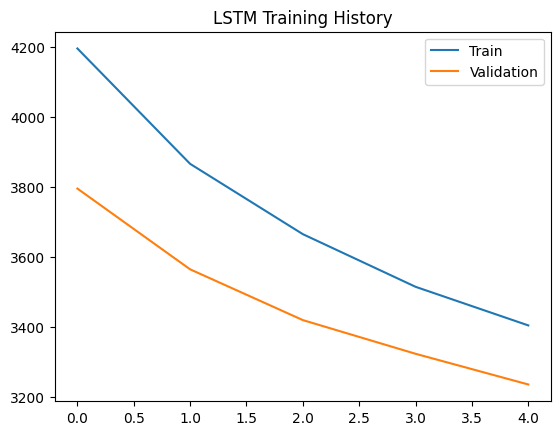

In [32]:
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.legend()
plt.title("LSTM Training History")
plt.show()

Evaluate refined forecast

In [33]:
# LSTM predicted residual
residual_pred = model.predict(X_val_lstm).flatten()

# Corresponding LightGBM predictions
lgb_pred_aligned = df_lstm["lgb_pred"].iloc[-len(residual_pred):].values

# Final hybrid prediction
hybrid_pred = lgb_pred_aligned + residual_pred
y_val_actual = df_lstm["solar_normalize"].iloc[-len(residual_pred):].values

175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step


Compare with LightGBM

In [37]:
#  lgb_val_actual = y_val_lstm
# lgb_val_pred   = df_lstm["lgb_pred"].iloc[-len(y_val_lstm):].values

Error comparison

In [36]:
print("LightGBM RMSE:",
      np.sqrt(mean_squared_error(y_val_actual, lgb_pred_aligned)),r2_score(y_val_actual, lgb_pred_aligned))

print("Hybrid LGBM + LSTM RMSE:",
      np.sqrt(mean_squared_error(y_val_actual, hybrid_pred)),r2_score(y_val_actual, hybrid_pred))


LightGBM RMSE: 67.51195302935955 0.9298263273093733
Hybrid LGBM + LSTM RMSE: 56.88665979510041 0.9501765574677591


Visual comparison

In [ ]:
plot